In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rfm = pd.read_csv('../data/processed/rfm_table.csv')
rfm.describe()

,Customer Id,Recency,Frequency,Monetary
count,20641.000000,20641.000000,20641.000000,20641.000000
mean,10397.009835,220.173926,3.184972,1781.953497
std,5992.846925,199.413614,2.430824,1677.429491
min,1.000000,0.000000,1.000000,11.290000
25%,5206.000000,75.000000,1.000000,293.040008
50%,10402.000000,159.000000,3.000000,1499.870029
75%,15591.000000,307.000000,5.000000,2919.540066
max,20757.000000,1125.000000,15.000000,10524.170178


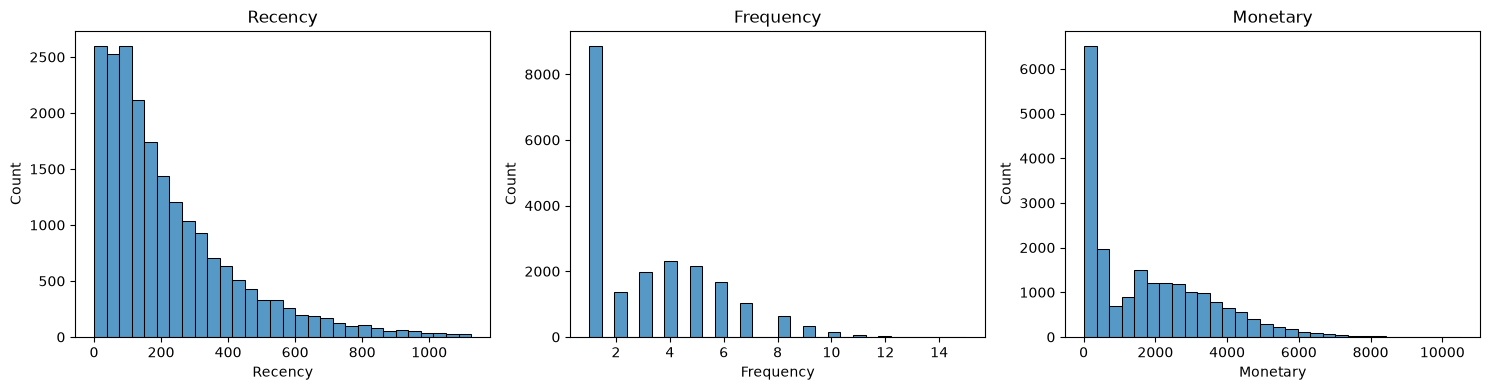

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
sns.histplot(rfm['Frequency'], bins=30, ax=axes[1])
sns.histplot(rfm['Monetary'], bins=30, ax=axes[2])
axes[0].set_title('Recency')
axes[1].set_title('Frequency')
axes[2].set_title('Monetary')
plt.tight_layout()
plt.show()

In [7]:
rfm.describe()

,Customer Id,Recency,Frequency,Monetary
count,20641.000000,20641.000000,20641.000000,20641.000000
mean,10397.009835,220.173926,3.184972,1781.953497
std,5992.846925,199.413614,2.430824,1677.429491
min,1.000000,0.000000,1.000000,11.290000
25%,5206.000000,75.000000,1.000000,293.040008
50%,10402.000000,159.000000,3.000000,1499.870029
75%,15591.000000,307.000000,5.000000,2919.540066
max,20757.000000,1125.000000,15.000000,10524.170178


In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler

rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency_log', 'Frequency_log', 'Monetary_log']])

rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])
rfm_scaled.describe()

,Recency_scaled,Frequency_scaled,Monetary_scaled
count,2.064100e+04,2.064100e+04,2.064100e+04
mean,-5.728129e-16,2.203127e-16,-1.762501e-16
std,1.000024e+00,1.000024e+00,1.000024e+00
min,-4.283718e+00,-1.021693e+00,-2.571329e+00
25%,-5.099800e-01,-1.021693e+00,-6.144406e-01
50%,1.387147e-01,2.062868e-01,3.902724e-01
75%,7.094077e-01,9.246092e-01,8.005955e-01
max,1.839008e+00,2.662247e+00,1.590765e+00


In [9]:
rfm_scaled.describe()

,Recency_scaled,Frequency_scaled,Monetary_scaled
count,2.064100e+04,2.064100e+04,2.064100e+04
mean,-5.728129e-16,2.203127e-16,-1.762501e-16
std,1.000024e+00,1.000024e+00,1.000024e+00
min,-4.283718e+00,-1.021693e+00,-2.571329e+00
25%,-5.099800e-01,-1.021693e+00,-6.144406e-01
50%,1.387147e-01,2.062868e-01,3.902724e-01
75%,7.094077e-01,9.246092e-01,8.005955e-01
max,1.839008e+00,2.662247e+00,1.590765e+00


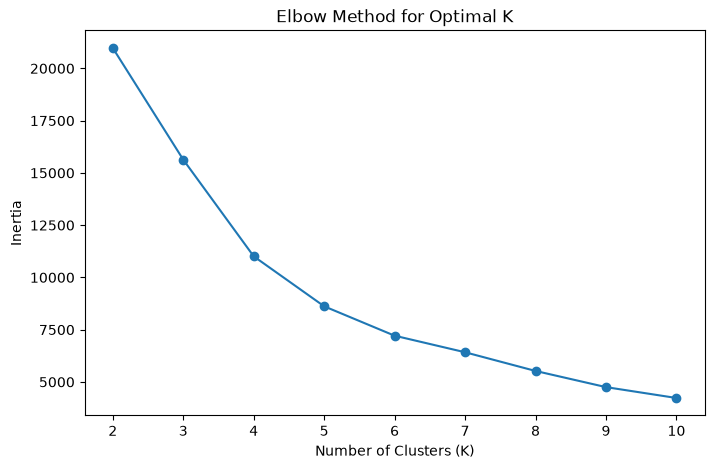

In [10]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

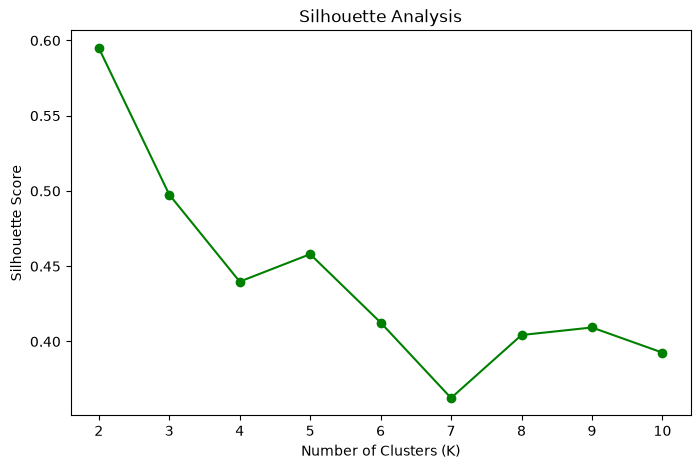

K=2: 0.5950
K=3: 0.4976
K=4: 0.4398
K=5: 0.4580
K=6: 0.4126
K=7: 0.3624
K=8: 0.4043
K=9: 0.4093
K=10: 0.3926


In [11]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: {score:.4f}")

In [12]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_summary['Count'] = rfm['Cluster'].value_counts().sort_index()
cluster_summary

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,254.1,5.9,3573.8,7568
1,11.0,1.0,86.0,1510
2,77.8,1.0,37.8,1623
3,450.2,2.7,1554.3,4648
4,73.0,1.0,438.2,5292


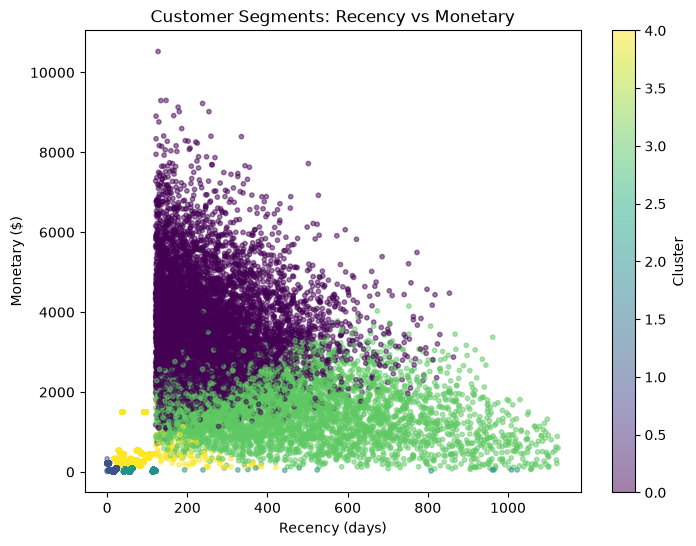

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', alpha=0.5, s=10)
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Monetary ($)')
ax.set_title('Customer Segments: Recency vs Monetary')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [14]:
segment_map = {
    0: 'Loyal / High-Value',
    1: 'New Customer',
    2: 'New / Low-Value',
    3: 'At Risk / Churned',
    4: 'Recent One-Time Buyer'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)
rfm.to_csv('../data/processed/rfm_segmented.csv', index=False)
rfm['Segment'].value_counts()

Segment
Loyal / High-Value       7568
Recent One-Time Buyer    5292
At Risk / Churned        4648
New / Low-Value          1623
New Customer             1510
Name: count, dtype: int64

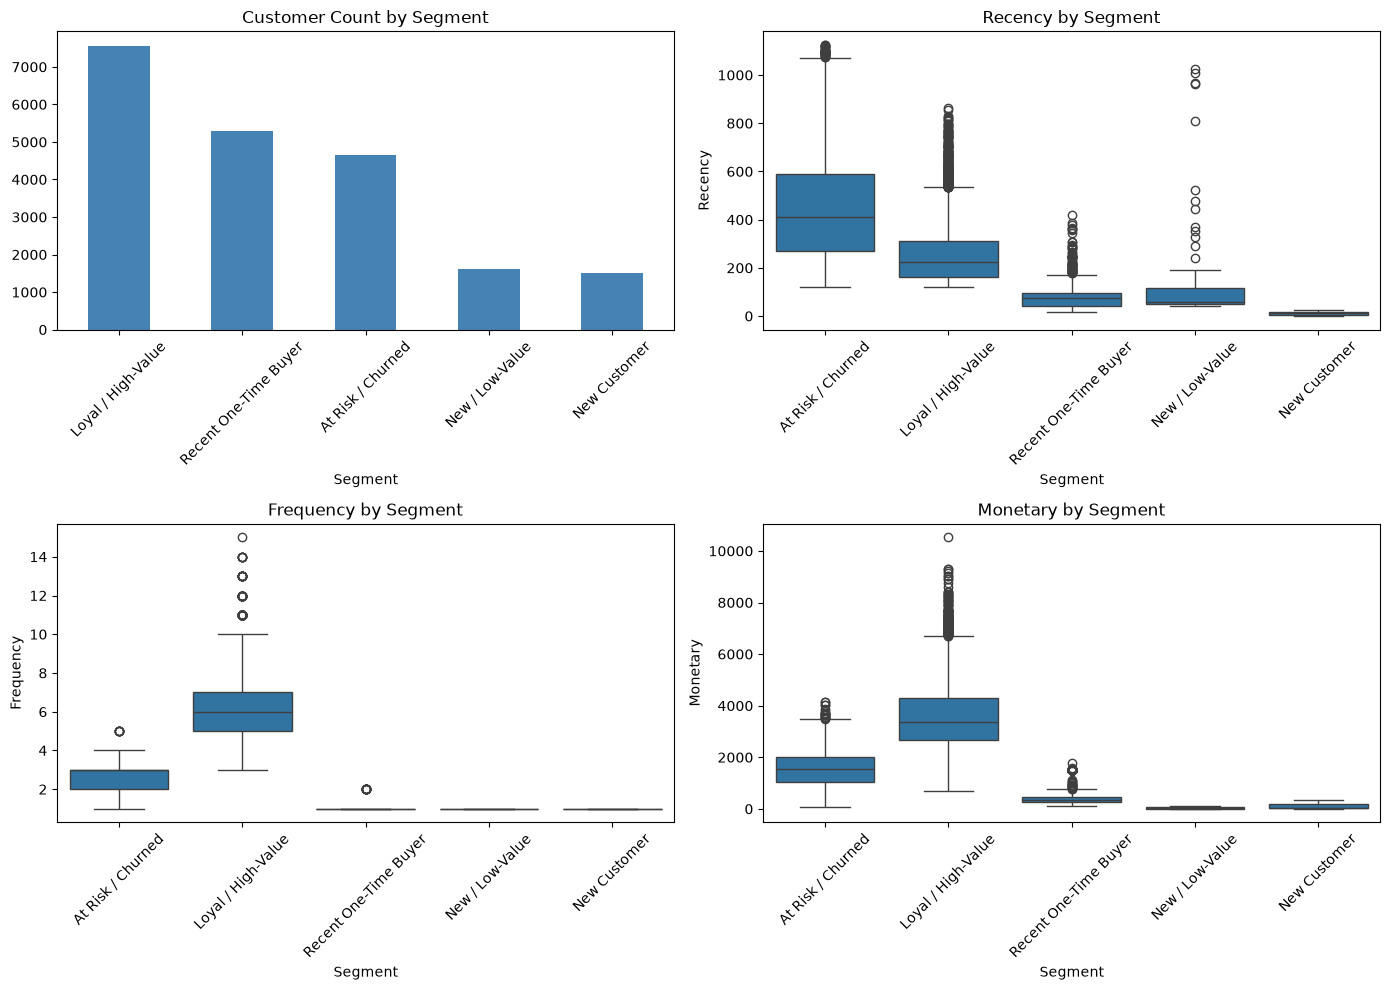

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rfm['Segment'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Customer Count by Segment')
axes[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=rfm, x='Segment', y='Recency', ax=axes[0,1])
axes[0,1].set_title('Recency by Segment')
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=rfm, x='Segment', y='Frequency', ax=axes[1,0])
axes[1,0].set_title('Frequency by Segment')
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=rfm, x='Segment', y='Monetary', ax=axes[1,1])
axes[1,1].set_title('Monetary by Segment')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [16]:
fig.savefig('../data/processed/segment_analysis.png', dpi=150, bbox_inches='tight')